# Content with notebooks

You can also create content with Jupyter Notebooks. This means that you can include
code blocks and their outputs in your book.

## Markdown + notebooks

As it is markdown, you can embed images, HTML, etc into your posts!

![](logo.jpg)

You can also $add_{math}$ and

$$
math^{blocks}
$$

or

$$
\begin{aligned}
\mbox{mean} la_{tex} \\ \\
math blocks
\end{aligned}
$$

But make sure you \$Escape \$your \$dollar signs \$you want to keep!

## MyST markdown

MyST markdown works in Jupyter Notebooks as well. For more information about MyST markdown, check
out [the MyST guide in Jupyter Book](https://jupyterbook.org/content/myst.html),
or see [the MyST markdown documentation](https://myst-parser.readthedocs.io/en/latest/).

## Code blocks and outputs

Jupyter Book will also embed your code blocks and output in your book.
For example, here's some sample Matplotlib code:

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import geopandas as gpd
import folium



In [5]:
df_taxi = pd.read_csv(r"C:\Users\PC\Desktop\data trabajo final\archive\yellow_tripdata_2019-01.csv")


In [6]:
df_taxi.shape

(7667792, 18)

In [7]:
def process_taxi_data(df_taxi):
    taxi = df_taxi[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID',
                   'DOLocationID','passenger_count', 'trip_distance','fare_amount','total_amount', 'payment_type', 'tolls_amount']].copy()
    # Renaming Columns
    new_names = {'tpep_pickup_datetime': 'PickUpDate', 'tpep_dropoff_datetime':'DropOffDate', 'passenger_count': 'Passengers', 
                 'trip_distance':'Distance'}
    taxi = taxi.rename(columns=new_names)
    # Correct Format in Date Columns
    taxi['PickUpDate'] = pd.to_datetime(taxi['PickUpDate'], format='%Y-%m-%d %H:%M:%S')
    taxi['DropOffDate'] = pd.to_datetime(taxi['DropOffDate'], format='%Y-%m-%d %H:%M:%S')
    # Create Columns for Date Analysis
    taxi['PickUpYear'] = taxi['PickUpDate'].dt.year
    taxi['PickUpMonth'] = taxi['PickUpDate'].dt.month
    taxi['PickUpWeek'] = taxi['PickUpDate'].dt.isocalendar().week
    taxi['PickUpDay'] = taxi['PickUpDate'].dt.day
    taxi['PickUpHour'] = taxi['PickUpDate'].dt.hour
    taxi['PickUpDayWeek'] = taxi['PickUpDate'].dt.dayofweek + 1 
    # Duration Column
    taxi['Duration'] = taxi['DropOffDate'] - taxi['PickUpDate']
    # Total Amount Column
    taxi['total_amount'] = taxi['total_amount'].abs()
    # Drop Date Columns
    taxi = taxi.drop(labels=['PickUpDate', 'DropOffDate'], axis=1)
    return taxi
taxi_df = process_taxi_data(df_taxi)

taxi_df = process_taxi_data(df_taxi)
taxi_df = taxi_df[['PULocationID', 'DOLocationID', 'Passengers', 'Distance', 'fare_amount', 'total_amount', 'PickUpYear', 'PickUpMonth', 'PickUpWeek', 'PickUpDay', 'PickUpHour', 'PickUpDayWeek','payment_type', 'tolls_amount', 'Duration' ]]
taxi_df.head()



,PULocationID,DOLocationID,Passengers,Distance,fare_amount,total_amount,PickUpYear,PickUpMonth,PickUpWeek,PickUpDay,PickUpHour,PickUpDayWeek,payment_type,tolls_amount,Duration
0,151,239,1,1.5,7.0,9.95,2019,1,1,1,0,2,1,0.0,0 days 00:06:40
1,239,246,1,2.6,14.0,16.30,2019,1,1,1,0,2,1,0.0,0 days 00:19:12
2,236,236,3,0.0,4.5,5.80,2018,12,51,21,13,5,1,0.0,0 days 00:04:10
3,193,193,5,0.0,3.5,7.55,2018,11,48,28,15,3,2,0.0,0 days 00:03:20
4,193,193,5,0.0,52.0,55.55,2018,11,48,28,15,3,2,0.0,0 days 00:01:36


In [9]:
negative_durations = taxi_df[taxi_df['Duration'] < pd.Timedelta(0)]
negative_durations

,PULocationID,DOLocationID,Passengers,Distance,fare_amount,total_amount,PickUpYear,PickUpMonth,PickUpWeek,PickUpDay,PickUpHour,PickUpDayWeek,payment_type,tolls_amount,Duration
1203127,100,79,1,3.3,16.00,16.80,2019,1,1,6,15,7,2,0.00,-59 days +11:19:30
2976251,164,145,3,7.6,29.50,36.06,2019,1,2,13,15,7,2,5.76,-20 days +16:22:16
4741726,186,162,1,1.9,15.50,19.55,2019,1,3,20,15,7,1,0.00,-2 days +00:41:46
5175736,265,265,1,0.0,3.52,3.77,2019,1,4,22,16,2,2,0.00,-1 days +23:59:00


In [10]:
taxi_df = taxi_df[taxi_df['Duration'] >= pd.Timedelta(0)]
taxi_df['Duration'].describe()

count                      7667788
mean     0 days 00:16:29.773001679
std      0 days 01:15:15.920851954
min                0 days 00:00:00
25%                0 days 00:06:06
50%                0 days 00:10:09
75%                0 days 00:16:34
max               30 days 07:28:01
Name: Duration, dtype: object

# **eliminar datos atípidos**

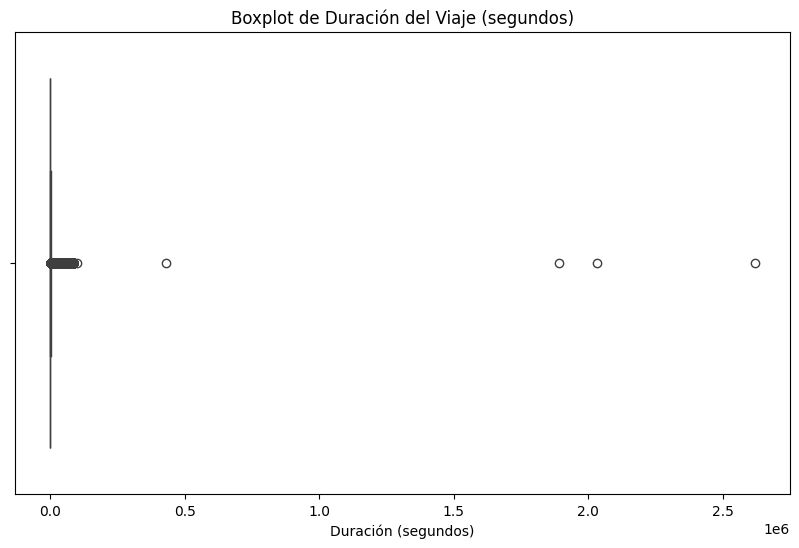

In [11]:
# Convertir la columna 'Duration' a números (segundos) para poder hacer un boxplot
taxi_df['Duration_seconds'] = taxi_df['Duration'].dt.total_seconds()

# Ahora puedes hacer un boxplot de 'Duration_seconds'
plt.figure(figsize=(10, 6))
sns.boxplot(x=taxi_df['Duration_seconds'])
plt.title('Boxplot de Duración del Viaje (segundos)')
plt.xlabel('Duración (segundos)')
plt.show()

In [12]:
# Convertir la columna 'Duration' a minutos
taxi_df['Duration_minutes'] = taxi_df['Duration'].dt.total_seconds() / 60

# Crear rangos de minutos
bins = [0, 11, 21, 31, 41, 51, 61, 71, 81, 91, 101, float('inf')]
labels = ['0-11', '11-21', '21-31', '31-41', '41-51', '51-61', '61-71', '71-81', '81-91', '91-101', '101+']

# Agrupar por rangos de minutos y contar las carreras
taxi_df['Duration_range'] = pd.cut(taxi_df['Duration_minutes'], bins=bins, labels=labels, include_lowest=True)
race_count_by_range = taxi_df.groupby('Duration_range')['Duration'].count()

race_count_by_range

C:\Users\PC\AppData\Local\Temp\ipykernel_19660\3245737099.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  race_count_by_range = taxi_df.groupby('Duration_range')['Duration'].count()


Duration_range
0-11      4171029
11-21     2299490
21-31      748375
31-41      260636
41-51      100123
51-61       40545
61-71       16582
71-81        6262
81-91        2153
91-101        790
101+        21803
Name: Duration, dtype: int64

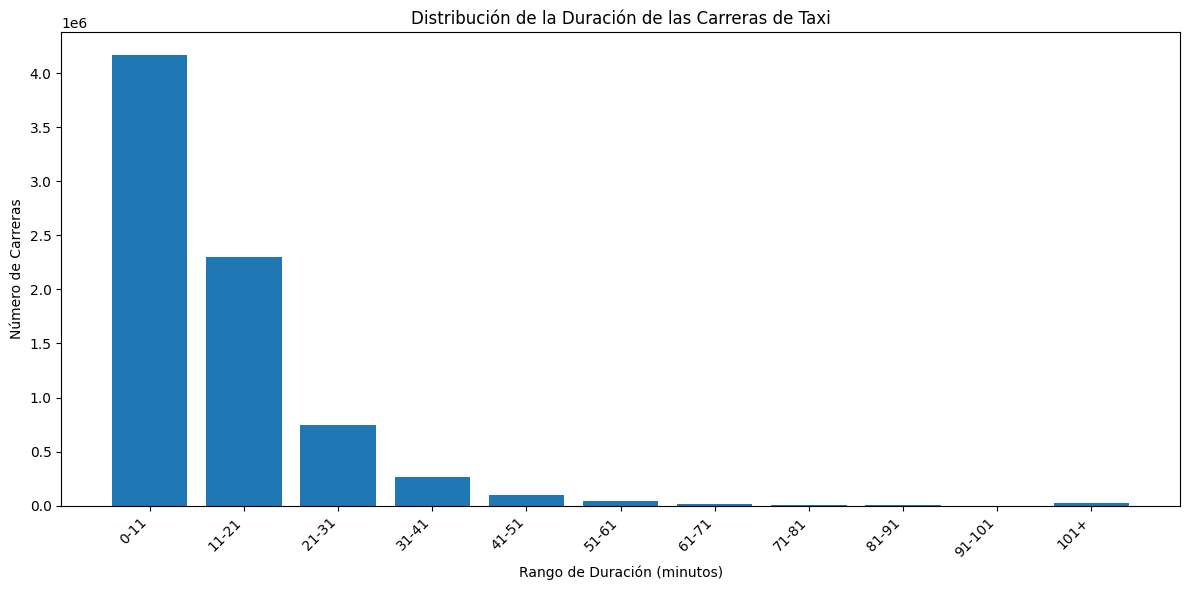

In [13]:
# Crear el gráfico de barras
plt.figure(figsize=(12, 6))  # Ajustar el tamaño del gráfico
plt.bar(race_count_by_range.index, race_count_by_range.values)

# Etiquetas y título del gráfico
plt.xlabel('Rango de Duración (minutos)')
plt.ylabel('Número de Carreras')
plt.title('Distribución de la Duración de las Carreras de Taxi')

# Rotar las etiquetas del eje x para una mejor legibilidad (opcional)
plt.xticks(rotation=45, ha='right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [14]:
# Check for NaN values in the DataFrame
nan_counts = taxi_df.isna().sum()

# Print the counts of NaN values for each column
print(nan_counts)

# Optionally, you can also check if there are any NaN values in the entire DataFrame
has_nan = taxi_df.isnull().values.any()
print(f"\nDoes the DataFrame contain NaN values? {has_nan}")

PULocationID        0
DOLocationID        0
Passengers          0
Distance            0
fare_amount         0
total_amount        0
PickUpYear          0
PickUpMonth         0
PickUpWeek          0
PickUpDay           0
PickUpHour          0
PickUpDayWeek       0
payment_type        0
tolls_amount        0
Duration            0
Duration_seconds    0
Duration_minutes    0
Duration_range      0
dtype: int64

Does the DataFrame contain NaN values? False


In [15]:

duplicate_rows = taxi_df[taxi_df.duplicated()]
num_duplicates = len(duplicate_rows)
print(f"Número de filas duplicadas: {num_duplicates}")

Número de filas duplicadas: 967


In [21]:
# Eliminar filas con valores NaN
taxi_df = taxi_df.dropna()

# Eliminar filas duplicadas
taxi_df = taxi_df.drop_duplicates()

# Verificar si se eliminaron los valores NaN y las filas duplicadas
nan_counts = taxi_df.isna().sum()
print(nan_counts)

duplicate_rows = taxi_df[taxi_df.duplicated()]
num_duplicates = len(duplicate_rows)
print(f"Número de filas duplicadas: {num_duplicates}")

PULocationID        0
DOLocationID        0
Passengers          0
Distance            0
fare_amount         0
total_amount        0
PickUpYear          0
PickUpMonth         0
PickUpWeek          0
PickUpDay           0
PickUpHour          0
PickUpDayWeek       0
payment_type        0
tolls_amount        0
Duration            0
Duration_seconds    0
DurationSeconds     0
DurationMinutes     0
Duration_minutes    0
Duration_range      0
dtype: int64
Número de filas duplicadas: 0


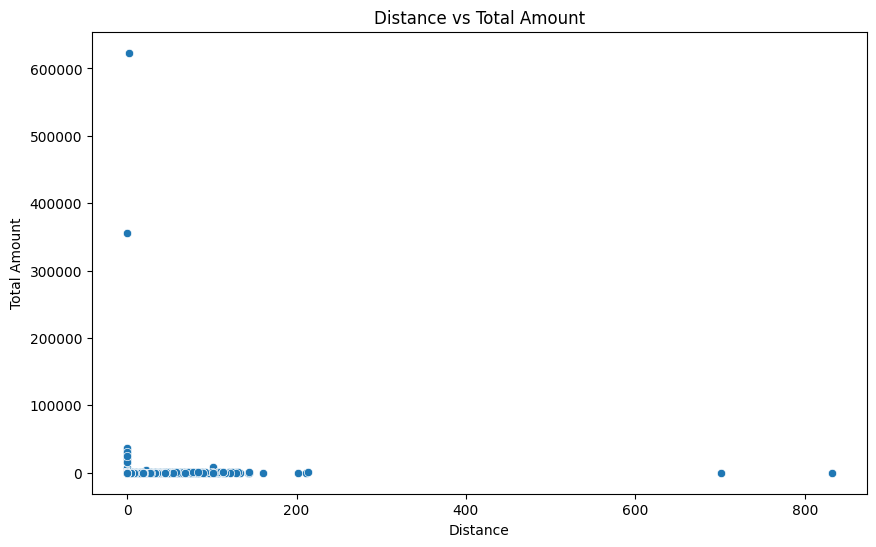

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Distance', y='total_amount', data=taxi_df)
plt.title('Distance vs Total Amount')
plt.xlabel('Distance')
plt.ylabel('Total Amount')
plt.show()


In [19]:
zonas_df = pd.read_csv(r"C:\Users\PC\Desktop\ML_clase\jbook_ml20251\data\taxi+_zone_lookup.csv")
# Unir el DataFrame de taxis con las zonas usando PULocationID
df_taxi = df_taxi.merge(zonas_df[['LocationID', 'Zone']], left_on='PULocationID', right_on='LocationID', how='left')

# Unir también el DOLocationID para obtener la zona de destino
df_taxi = df_taxi.merge(zonas_df[['LocationID', 'Zone']], left_on='DOLocationID', right_on='LocationID', how='left', suffixes=('_pickup', '_dropoff'))

In [22]:
# Coordenadas de algunas zonas de recogida y entrega (ejemplo)
pickup_zones_coords = {
    'Manhattan Valley': [40.8071, -73.9610],
    'Upper West Side South': [40.7850, -73.9750],
    'Upper East Side North': [40.7847, -73.9523],
    'Queensbridge/Ravenswood': [40.7612, -73.9442],
    'Midtown North': [40.7549, -73.9808],
    'Sutton Place/Turtle Bay North': [40.7566, -73.9689],
    'Lenox Hill West': [40.7661, -73.9630],
    'West Chelsea/Hudson Yards': [40.7475, -74.0024],
    'Stuy Town/Peter Cooper Village': [40.7311, -73.9790],
    'Murray Hill': [40.7450, -73.9819],
    'Gramercy': [40.7365, -73.9857],
    'Central Harlem': [40.8115, -73.9465],
    'Hamilton Heights': [40.8230, -73.9453],
    'Greenwich Village North': [40.7375, -73.9987],
    'Midtown Center': [40.7550, -73.9850],
    'LaGuardia Airport': [40.7769, -73.8737],
    'Little Italy/NoLiTa': [40.7223, -73.9963],
    'TriBeCa/Civic Center': [40.7168, -74.0070],
    'Upper East Side South': [40.7736, -73.9567],
    'Yorkville West': [40.7741, -73.9503],
    'JFK Airport': [40.6413, -73.7781],
    'NV': [40.7038, -74.0148],
    'Lincoln Square East': [40.7713, -73.9863],
    'West Village': [40.7336, -74.0033],
    'Kips Bay': [40.7422, -73.9763],
    'Flatiron': [40.7411, -73.9897],
    'Midtown East': [40.7551, -73.9760],
    'Lenox Hill East': [40.7673, -73.9579],
    'East Chelsea': [40.7450, -73.9989],
    'Financial District South': [40.7057, -74.0125],
    'East Harlem North': [40.7954, -73.9384],
    'East Village': [40.7250, -73.9816],
    'East Harlem South': [40.7982, -73.9405],
    'UN/Turtle Bay South': [40.7484, -73.9680],
    'Lower East Side': [40.7158, -73.9848],
    'Clinton East': [40.7590, -73.9900],
    'Lincoln Square West': [40.7702, -73.9873],
    'Alphabet City': [40.7261, -73.9819],
    'Midtown South': [40.7440, -73.9930],
    'Two Bridges/Seward Park': [40.7110, -73.9865],
    'Chinatown': [40.7150, -73.9985],
    'Central Park': [40.7851, -73.9683],
    'Penn Station/Madison Sq West': [40.7500, -73.9933],
    'Meatpacking/West Village West': [40.7400, -74.0065],
    'Clinton West': [40.7485, -73.9962],
    'Greenwich Village South': [40.7323, -73.9988],
    'Central Harlem North': [40.8105, -73.9440],
    'Bay Ridge': [40.6300, -74.0280],
    'Bath Beach': [40.6075, -73.9887],
    'Park Slope': [40.6625, -73.9895],
    'SoHo': [40.7244, -73.9973],
    'Battery Park City': [40.7130, -74.0160],
    'World Trade Center': [40.7115, -74.0134],
    'Fort Greene': [40.6928, -73.9745],
    'Union Sq': [40.7359, -73.9911],
    'Hudson Sq': [40.7275, -74.0063],
    'Long Island City/Hunters Point': [40.7451, -73.9524],
    'Yorkville East': [40.7729, -73.9511],
    'Sunnyside': [40.7461, -73.9245],
    'Bloomingdale': [40.7620, -73.9886],
    'Morningside Heights': [40.8100, -73.9640],
    'East Williamsburg': [40.7106, -73.9499],
    'Prospect Heights': [40.6740, -73.9640],
    'Brooklyn Heights': [40.6960, -73.9970],
    'Garment District': [40.7550, -73.9940],
    'Hunts Point': [40.8270, -73.8798],
    'Melrose South': [40.8190, -73.9190],
    'Washington Heights South': [40.8450, -73.9400],
    'Washington Heights North': [40.8630, -73.9310],
    'Seaport': [40.7090, -74.0036],
    'Financial District North': [40.7080, -74.0100],
    'Boerum Hill': [40.6834, -73.9912],
    'Woodside': [40.7459, -73.8881],
    'Steinway': [40.7651, -73.9065],
    'Rego Park': [40.7255, -73.8576],
    'Manhattanville': [40.8250, -73.9575],
    'Times Sq/Theatre District': [40.7580, -73.9855],
    'Astoria': [40.7644, -73.9249],
    'DUMBO/Vinegar Hill': [40.7033, -73.9870],
    'Sunset Park West': [40.6402, -74.0103],
    'University Heights/Morris Heights': [40.8670, -73.9204],
    'Kew Gardens': [40.7197, -73.8449],
    'Downtown Brooklyn/MetroTech': [40.6928, -73.9866],
    'Jackson Heights': [40.7511, -73.8830],
    'Elmhurst': [40.7411, -73.8805],
    'Red Hook': [40.6754, -74.0143],
    'Williamsburg (North Side)': [40.7162, -73.9546],
    'Old Astoria': [40.7712, -73.9221],
    'Mount Hope': [40.8616, -73.8942],
    'Flatbush/Ditmas Park': [40.6367, -73.9625],
    'Bushwick South': [40.6770, -73.9210],
    'Bedford': [40.7113, -73.9551],
    'Stuyvesant Heights': [40.6754, -73.9200],
    'Battery Park': [40.7072, -74.0134],
    'Cobble Hill': [40.6857, -73.9982],
    'Greenpoint': [40.7400, -73.9510],
    'Williamsburg (South Side)': [40.7086, -73.9571],
    'Crown Heights North': [40.6710, -73.9440],
    'Windsor Terrace': [40.6602, -73.9760],
    'South Jamaica': [40.6699, -73.8046],
    'East Elmhurst': [40.7615, -73.8784],
    'South Williamsburg': [40.7102, -73.9617],
    'Ocean Hill': [40.6761, -73.9189],
    'Clinton Hill': [40.6851, -73.9586],
    'Mott Haven/Port Morris': [40.8084, -73.9143],
    'East New York': [40.6699, -73.8710],
    'Kensington': [40.6432, -73.9774],
    'Ridgewood': [40.7012, -73.9073],
    'Carroll Gardens': [40.6844, -73.9960],
    'West Concourse': [40.8235, -73.9045],
    'Williamsbridge/Olinville': [40.8794, -73.8681],
    'South Ozone Park': [40.6752, -73.8261],
    'East New York/Pennsylvania Avenue': [40.6747, -73.8877],
    'Westchester Village/Unionport': [40.8401, -73.8694],
    'Highbridge': [40.8470, -73.9240],
    'Gowanus': [40.6750, -73.9890],
    'Schuylerville/Edgewater Park': [40.8580, -73.8267],
    'Crotona Park East': [40.8499, -73.9072],
    'Long Island City/Queens Plaza': [40.7445, -73.9482],
    'Queens Village': [40.7280, -73.7705],
    'Columbia Street': [40.6785, -73.9942],
    'Saint Albans': [40.6950, -73.7734],
    'Bushwick North': [40.7039, -73.9227],
    'Marble Hill': [40.8692, -73.9195],
    'Brooklyn Navy Yard': [40.7241, -73.9755],
    'East Tremont': [40.8614, -73.8670],
    'Jamaica': [40.6695, -73.7950],
    'Van Cortlandt Village': [40.8766, -73.9025],
    'East Concourse/Concourse Village': [40.8382, -73.9266],
    'Howard Beach': [40.6565, -73.8477],
    'Prospect Park': [40.6602, -73.9689],
    'Rosedale': [40.6715, -73.7628],
    'Bellerose': [40.7363, -73.7498],
    'Soundview/Castle Hill': [40.8287, -73.8580],
    'Baisley Park': [40.6744, -73.8192],
    'Springfield Gardens North': [40.6665, -73.7708],
    'Norwood': [40.8760, -73.8902],
    'West Farms/Bronx River': [40.8374, -73.8591],
    'Starrett City': [40.6446, -73.8583],
    'Maspeth': [40.7297, -73.9022],
    'Middle Village': [40.7343, -73.8880],
    'Prospect-Lefferts Gardens': [40.6550, -73.9608],
    'Flushing Meadows-Corona Park': [40.7491, -73.8447],
    'Homecrest': [40.6023, -73.9667],
    'Corona': [40.7423, -73.8608],
    'Richmond Hill': [40.6958, -73.8318]
}

dropoff_zones_coords = {
    'Upper West Side South': [40.7762, -73.9822],
    'West Chelsea/Hudson Yards': [40.7475, -74.0024],
    'Astoria': [40.7644, -73.9249],
    'Union Sq': [40.7359, -73.9911],
    'Midtown East': [40.7551, -73.9760],
    'Manhattan Valley': [40.8071, -73.9610],
    'Boerum Hill': [40.6834, -73.9912],
    'Murray Hill': [40.7450, -73.9819],
    'Gramercy': [40.7365, -73.9857],
    'Lenox Hill West': [40.7661, -73.9630],
    'Central Harlem': [40.8115, -73.9465],
    'Hamilton Heights': [40.8230, -73.9453],
    'Greenwich Village North': [40.7375, -73.9987],
    'Midtown Center': [40.7550, -73.9850],
    'LaGuardia Airport': [40.7769, -73.8737],
    'Little Italy/NoLiTa': [40.7223, -73.9963],
    'TriBeCa/Civic Center': [40.7168, -74.0070],
    'Upper East Side South': [40.7736, -73.9567],
    'Yorkville West': [40.7741, -73.9503],
    'JFK Airport': [40.6413, -73.7781],
    'NV': [40.7038, -74.0148],
    'Lincoln Square East': [40.7713, -73.9863],
    'West Village': [40.7336, -74.0033],
    'Kips Bay': [40.7422, -73.9763],
    'Flatiron': [40.7411, -73.9897],
    'Midtown East': [40.7551, -73.9760],
    'Lenox Hill East': [40.7673, -73.9579],
    'East Chelsea': [40.7450, -73.9989],
    'Financial District South': [40.7057, -74.0125],
    'East Harlem North': [40.7954, -73.9384],
    'East Village': [40.7250, -73.9816],
    'East Harlem South': [40.7982, -73.9405],
    'UN/Turtle Bay South': [40.7484, -73.9680],
    'Lower East Side': [40.7158, -73.9848],
    'Clinton East': [40.7590, -73.9900],
    'Lincoln Square West': [40.7702, -73.9873],
    'Alphabet City': [40.7261, -73.9819],
    'Midtown South': [40.7440, -73.9930],
    'Two Bridges/Seward Park': [40.7110, -73.9865],
    'Chinatown': [40.7150, -73.9985],
    'Central Park': [40.7851, -73.9683],
    'Penn Station/Madison Sq West': [40.7500, -73.9933],
    'Meatpacking/West Village West': [40.7400, -74.0065],
    'Clinton West': [40.7485, -73.9962],
    'Greenwich Village South': [40.7323, -73.9988],
    'Central Harlem North': [40.8105, -73.9440]
    # Continúa añadiendo más zonas de dropoff según sea necesario...
}


# Crear el mapa centrado en el centro de NYC
m = folium.Map(location=[40.7128, -74.0060], zoom_start=12)

# Función para añadir zonas al mapa con coordenadas y color
def add_zone_to_map(zones_coords, color):
    for zone, coords in zones_coords.items():
        folium.Marker(coords, popup=zone, icon=folium.Icon(color=color)).add_to(m)

# Añadir zonas de recogida (azul)
add_zone_to_map(pickup_zones_coords, 'blue')

# Añadir zonas de entrega (rojo)
add_zone_to_map(dropoff_zones_coords, 'red')

m

There is a lot more that you can do with outputs (such as including interactive outputs)
with your book. For more information about this, see [the Jupyter Book documentation](https://jupyterbook.org)